<center>

**Text Mining Project** <br> Master in Data Science and Advanced Analytics <br>

NOVA Information Management School <br> Universidade Nova de Lisboa

</center>

<center> 
<b><font size="6" color="#0ee071">Tweets-Based Market Sentiment</font></b> 
</center>


<font color="#0ee071"> **Group 25 - June 2025** </font>

- Beatris Daicu, 20221854
- Diogo Carvalho, 20221935
- Ricardo Pereira, 20250343
- Yehor Malakhov, 20221691


<b><font size="5" color="#0ee071"> Introduction </font></b>

Over time, major indexes go up and down based on internal and external factors.
Performance like that excites investors, but typically in opposite ways.
Constant gains lead some investors to expect more of the same. Others worry the
good times are surely about to end. The former sentiment is sometimes called
**bullish**, while the latter is referred to as **bearish**.

The goal of this project is to develop an NLP model capable of predicting Market
sentiment based on tweets, that is predicting the variable `label`, where it
describes a **Bearish** (0), **Bullish** (1), or **Neutral** (2) attitude.


### <font color='#0ee071'>Table of Contents </font> <a class="anchor" id='index'></a>

- [I. **Data Exploration**](#P1)
  - [Data Overview](#P1.1)
  - [Text Overview](#P1.2)
    - [Raw Text](#P1.2.1)
    - [Processed Text](#P1.2.2)
    - [Encoded Text](#P1.2.3)
    - [Encoded Text Vizualization](#P1.2.4)
- [II. **Classification Models**](#P2)
  - [Bag of Words Data](#P2.1)
    - [KNN Model](#P2.1.1)
    - [Random Forest Model](#P2.1.2)
    - [Model Analysis](#P2.1.3)
  - [Word2Vec Data](#P2.2)
    - [KNN Model](#P2.2.1)
    - [Random Forest Model](#P2.2.2)
    - [Model Analysis](#P2.2.3)
  - [Transformers Data](#P2.3)
    - [KNN Model](#P2.3.1)
    - [Random Forest Model](#P2.3.2)
    - [Model Analysis](#P2.3.3)
  - [Transformer Classifier](#P2.4)
    - [BERT](#P2.4.1)
    - [DistilBERT](#P2.4.2)


In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
from typing import TYPE_CHECKING, cast

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import torch
import tqdm
import umap
from deep_translator import GoogleTranslator
from lingua import LanguageDetectorBuilder
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
)
from sklearn.model_selection import ParameterSampler, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from wordcloud import WordCloud

from utils.encoders import (
    encode_bow,
    encode_trans,
    encode_w2v,
    load_model,
    train_word2vec_model,
)
from utils.preprocess import pipeline, text_cleaner
from utils.transformer_classifier import train_model
from utils.utils import visualize_dimensionality_reduction

if TYPE_CHECKING:
    import numpy as np

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

os.makedirs("plots", exist_ok=True)

In [2]:
nltk.download("stopwords", quiet=True)
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\carva\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\carva\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\carva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\carva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
STOPWORDS = set(stopwords.words("English")).difference(
    {
        "up",
        "down",
        "above",
        "below",
        "under",
        "over",
        "more",
        "less",
        "against",
        "but",
        "not",
        "no",
    }
)

KNN_GRID = {
    "n_neighbors": [*range(1, 16, 2)],
    "weights": ["uniform", "distance"],
    "p": [1, 2, 3],
}

RF_GRID = {
    "n_estimators": [*range(10, 251, 10)],
    "criterion": ["gini", "entropy"],
    "max_depth": [*range(1, 11)],
    "min_samples_split": [2**p for p in range(1, 11)],
    "min_samples_leaf": [2**p for p in range(11)],
    "max_features": ["sqrt", "log2", 1],
}

SEED = 42

# <font color="#0ee071"> I. Data Exploration <a class="anchor" id="P1"></a></font>

[Back to Index](#index)

This initial phase focuses on understanding the data and vizualizing insights
found in it. To simplify further work we decided to immediatly perform the
**Corpus Split**. Out of original `train_full` data 80% went onto being used for
training and 20% to be used as a validation data.


In [4]:
train_full = pd.read_csv("data/train.csv")
train, validation = train_test_split(
    train_full, test_size=0.2, stratify=train_full["label"], random_state=SEED
)
test = pd.read_csv("data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
96,Norwegian Cruise Line downgraded to strong sel...,0
1852,"Salesforce, Amazon taking on RingCentral",2
1038,Tri Global Energy Maintains Lead in Texas Wind...,1


,text,label
7109,Wall Street rallies on Friday but multi-week w...,2
7576,GE taps Maersk's Carolina Dybeck Happe as new ...,2
578,Fed's Mester says she opposed recent series of...,2


,text
id,
1366,The bond market is looking 'overbought' even i...
1812,$MTH - Meritage Homes 1Q20 orders rise 23% Y/Y...
2099,$TXN highs out of a long base and above 8 and ...


## <font color="#0ee071"> Data Overview <a class="anchor" id="P1.1"></a></font>

[Back to Index](#index)

In this chapter we only acess the data that is independent of the content of the
corpora. Note absence of missing values and a large ammount of Neutral texts.


In [5]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,Nasdaq prices 600M of 0.875% senior notes
freq,1


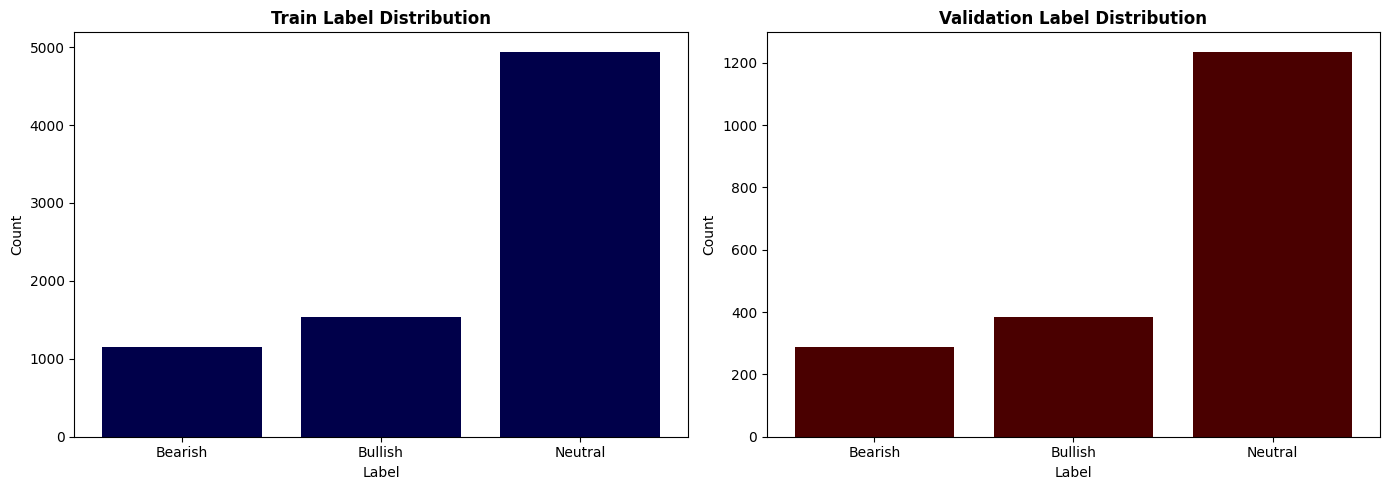

In [6]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(
    x=["Bearish", "Bullish", "Neutral"],
    height=train.groupby("label")["text"].count().to_list(),  # order by 0, 1, 2
    color="#00004A",
)

ax[1].bar(
    x=["Bearish", "Bullish", "Neutral"],
    height=validation.groupby("label")["text"]
    .count()
    .to_list(),  # order by 0, 1, 2
    color="#4A0000",
)

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title("Train Label Distribution", fontweight="bold")

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title("Validation Label Distribution", fontweight="bold")

plt.tight_layout()
plt.savefig("plots/correct_split.png")
plt.show()

## <font color="#0ee071"> Text Overview <a class="anchor" id="P1.2"></a></font>

[Back to Index](#index)

In this chapter we will overview data on different stages of our pipeline:

- before preprocessing (raw state)
- after preprocessing (clean state)
- after encoding

For first two states we overviewed text distributions via WordClouds an Bar
Charts. The Encoded State was analysed using UMAP, to simplify the complexity of
such high-dimentional data.


### <font color="#0ee071"> Raw Text <a class="anchor" id="P1.2.1"></a></font>

[Back to Index](#index)

As can be seen at first corpora has a large ammount of stopwords, which is to be
expected and has a bimodal distribution of length of text, peaking at cerca 60
and 140 elements.


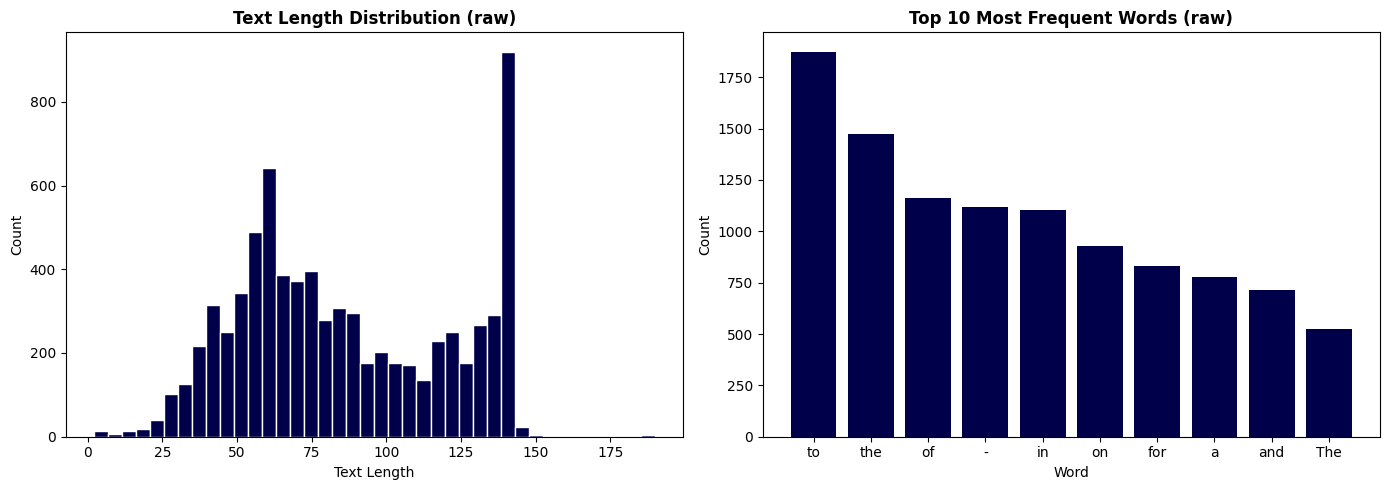

In [7]:
freq_raw = pd.Series(" ".join(train["text"]).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(train.text.str.len(), bins=40, color="#00004A", edgecolor="white")

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

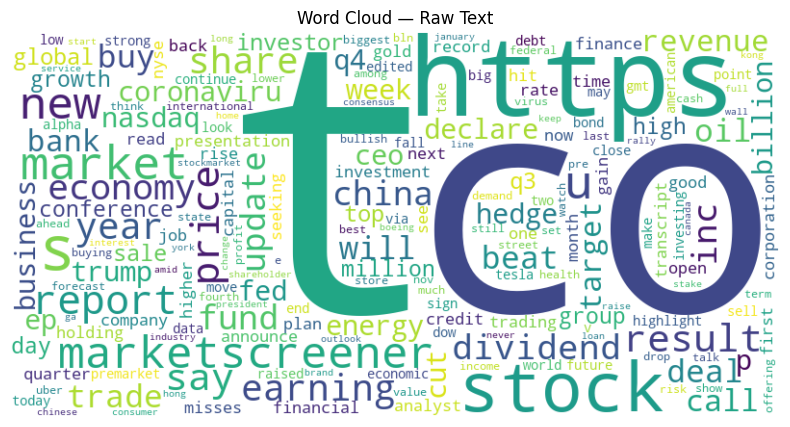

In [8]:
raw_text = " ".join(train["text"]).lower()
raw_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False,
    random_state=SEED,
).generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Raw Text")
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### <font color="#0ee071"> Processed Text <a class="anchor" id="P1.2.2"></a></font>

[Back to Index](#index)

In this part we cleaned the corpora in following manner:

1. Apply Cleaning Techniques from `utils.preprocessing.text_cleaner`
2. Detect Non-English Observations in Corpora
3. Translate Non-English Observations
4. Apply Cleaning Techniques from `utils.preprocessing.text_cleaner` to
   Translated Text. \
   (N.B. Translator might change puntuation and formatting)
5. Tokenize Final Text and Perform Final Transformations (i.e. stopwords removal
   and lemmatization)


In [9]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
3418,"BrightView Holdings EPS beats by $0.08, beats ...",1,brightview holdings eps beats by 0 08 beats on...
7153,BJP Issues Whip To Its MPs Asking Them To Be P...,2,bjp issues whip to its mps asking them to be p...
3245,"World Coal Association : CCS regains momentum,...",2,world coal association ccs regains momentum bu...
9471,Why Tiffany Stock Just Popped 6%,1,why tiffany stock just popped 6 percent
2074,Disney responds to data breach after thousands...,0,disney responds to data breach after thousands...


,text,label,text_clean
3419,"Bristol-Myers Squibb EPS beats by $0.28, beats...",1,bristol myers squibb eps beats by 0 28 beats o...
2475,DocuSign signs off on another solid earnings r...,1,docusign signs off on another solid earnings r...
4495,Gen Z explains the number 1 thing they're savi...,2,gen z explains the number 1 thing they are sav...
3427,"Chegg EPS beats by $0.06, beats on revenue",1,chegg eps beats by 0 06 beats on revenue
5180,The billionaire candidate said employees at hi...,2,the billionaire candidate said employees at hi...


In [10]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [
    lang.name.lower() if lang else None for lang in languages_train
]

languages_validation = detector.detect_languages_in_parallel_of(
    validation.text_clean
)
validation["language"] = [
    lang.name.lower() if lang else None for lang in languages_validation
]

non_eng_train = train[train["language"] != "english"][
    "text_clean"
].index.to_list()
non_eng_validation = validation[validation["language"] != "english"][
    "text_clean"
].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
6409,U.S. Claims for Jobless Benefits Fall to Lowes...,1,you s claims for jobless benefits fall to lowe...,english
6336,"Dubai economy grew 2.1% in first half of 2019,...",1,dubai economy grew 2 1 percent in first half o...,english
6204,The New York Fed's March survey of consumer ex...,0,the new york fed march survey of consumer expe...,english
7704,Amazon’s Cloud Battle With Microsoft Weighs on...,0,amazon s cloud battle with microsoft weighs on...,english
419,UAE stimulus to help bank liquidity but may in...,0,uae stimulus to help bank liquidity but may in...,english


In [11]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?
# NB probably stochastic and has no seed

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
        )
    )
).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
        )
    )
).to_list()

In [12]:
train["text_tokens"] = pipeline(
    train["text_clean"], to_clean=False, stopwords_list=STOPWORDS
)
validation["text_tokens"] = pipeline(
    validation["text_clean"], to_clean=False, stopwords_list=STOPWORDS
)

As expected the length distribution changed with observation getting shorter.
Notice still present two modes, one is still at cerca 60, but other lowered
to 110. Concerning top words, the most common two words became the handlers we
used to replace **urls** and **stock references**.


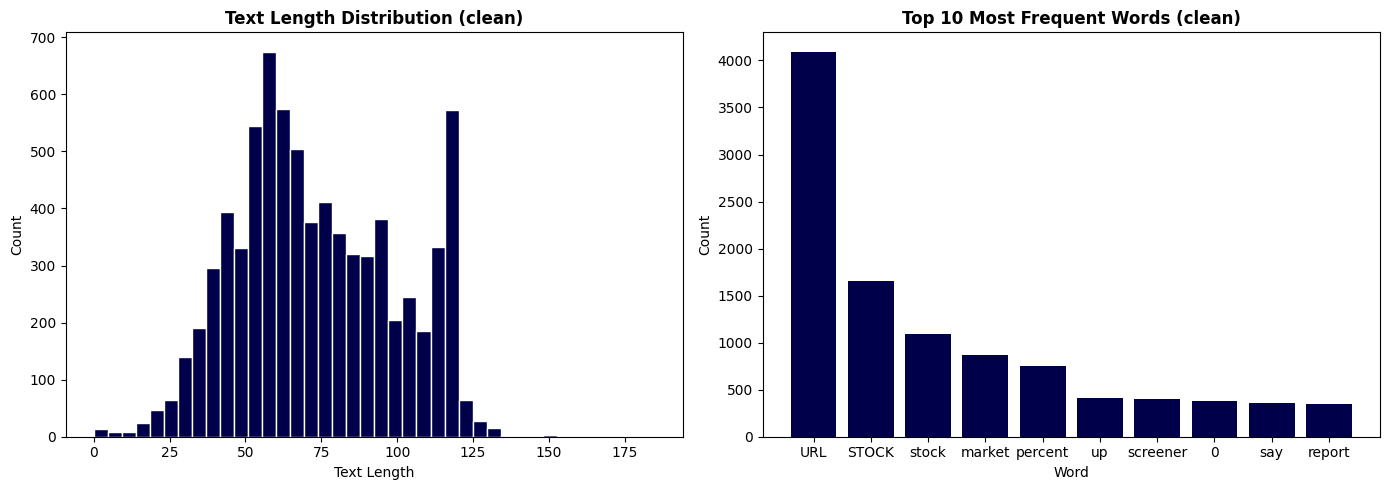

In [13]:
train["text_clean_joined"] = train["text_tokens"].apply(" ".join)
validation["text_clean_joined"] = validation["text_tokens"].apply(" ".join)

freq_clean = pd.Series(
    " ".join(train["text_clean_joined"]).split()
).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
    train.text_clean.str.len(), bins=40, color="#00004A", edgecolor="white"
)
ax[1].bar(
    freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A"
)

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

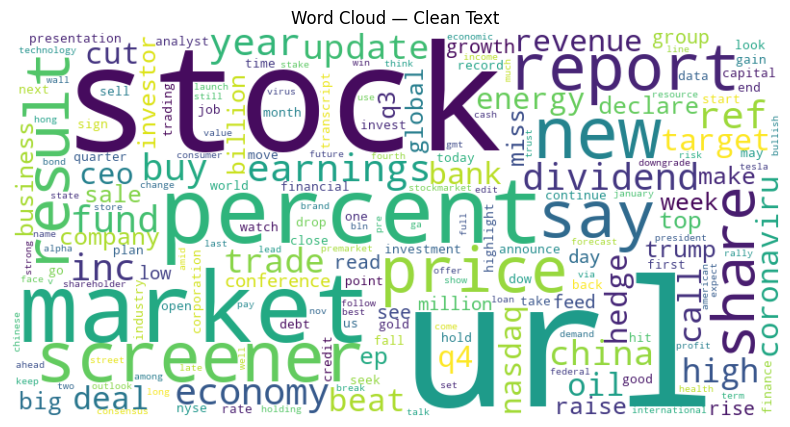

In [14]:
raw_text = " ".join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False,
    random_state=SEED,
).generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Clean Text")
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()

### <font color="#0ee071"> Encoded Text <a class="anchor" id="P1.2.3"></a></font>

[Back to Index](#index)


In [15]:
train_bow, bow_encoder = encode_bow(train["text_tokens"], min_df=30)

w2v_encoder = train_word2vec_model(train["text_tokens"], vector_size=35)
train_vec = encode_w2v(train["text_tokens"], w2v_encoder)

tokenizer, model = load_model("bert-base-uncased", device=DEVICE)
train_trans = encode_trans(train["text_clean_joined"], tokenizer, model, DEVICE)

train_label = train["label"]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [16]:
validation_bow = encode_bow(
    validation["text_tokens"], encoder=bow_encoder, return_bow=False
)
validation_vec = encode_w2v(validation["text_tokens"], w2v_encoder)
validation_trans = encode_trans(
    validation["text_clean_joined"], tokenizer, model, DEVICE
)

validation_label = validation["label"]

### <font color="#0ee071"> Encoded Text Vizualization <a class="anchor" id="P1.2.4"></a></font>

[Back to Index](#index)

As can be seen from visualisation all three encodings still are most definetly
not linearaly separatable, therefore we should expect some difficulty for our
models to learn.


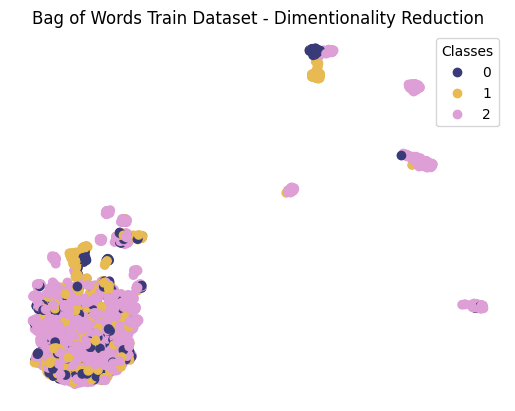

In [17]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.9, random_state=SEED)
umap_embedding: np.ndarray[tuple[int, int], np.dtype[np.float32]] = cast(
    "np.ndarray[tuple[int, int], np.dtype[np.float32]]",
    umap_object.fit_transform(train_bow),
)
visualize_dimensionality_reduction(
    umap_embedding,
    train_label,
    save_to=r"plots/bow_umap.png",
    title="Bag of Words Train Dataset - Dimentionality Reduction",
)

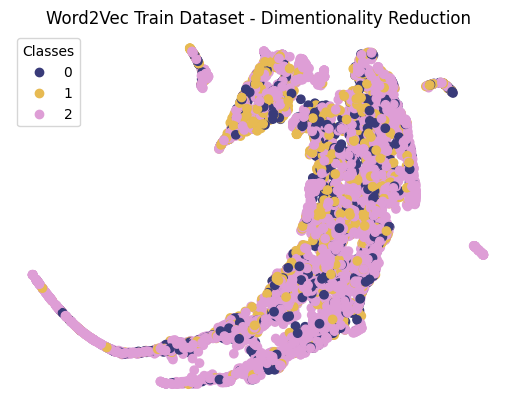

In [18]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=SEED)
umap_embedding: np.ndarray[tuple[int, int], np.dtype[np.float32]] = cast(
    "np.ndarray[tuple[int, int], np.dtype[np.float32]]",
    umap_object.fit_transform(train_vec),
)
visualize_dimensionality_reduction(
    umap_embedding,
    train_label,
    save_to=r"plots/w2v_umap.png",
    title="Word2Vec Train Dataset - Dimentionality Reduction",
)

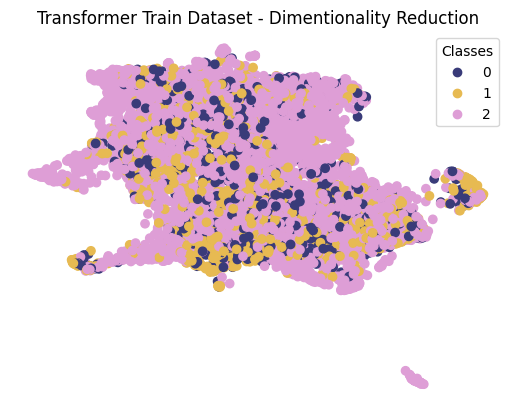

In [19]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=SEED)
umap_embedding: np.ndarray[tuple[int, int], np.dtype[np.float32]] = cast(
    "np.ndarray[tuple[int, int], np.dtype[np.float32]]",
    umap_object.fit_transform(train_trans),
)
visualize_dimensionality_reduction(
    umap_embedding,
    train_label,
    save_to="plots/trans_umap.png",
    title="Transformer Train Dataset - Dimentionality Reduction",
)

# <font color="#0ee071"> II. Classification Models <a class="anchor" id="P2"></a></font>

[Back to Index](#index)

In this chapter we decided to try two models for each encoding we used. The two
algorithms of choice were **K-Nearest Neigbours** and **Random Forest**. For
each model we run a Hyperparameter Tuning with Random Search with 30 iterations.


## <font color="#0ee071"> Bag of Words Data <a class="anchor" id="P2.1"></a></font>

[Back to Index](#index)


### <font color="#3676FF"> KNN Model <a class="anchor" id="P2.1.1"></a></font>

[Back to Index](#index)


In [20]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(KNN_GRID, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_bow, train_label)

    new_score = recall_score(
        validation_label, _knn.predict(validation_bow), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [00:42<00:00,  1.41s/it]

Best Recall: 0.60565
Grid: {'weights': 'distance', 'p': 2, 'n_neighbors': 3}


In [21]:
knn_classifier = (
    KNeighborsClassifier().set_params(**best_grid).fit(train_bow, train_label)
)
knn_predicted = knn_classifier.predict(validation_bow)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        knn_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.55      0.39      0.46       288
     Bullish       0.69      0.52      0.59       385
     Neutral       0.79      0.91      0.85      1236

    accuracy                           0.75      1909
   macro avg       0.68      0.61      0.63      1909
weighted avg       0.74      0.75      0.74      1909



### <font color="#3676FF"> Random Forest Model <a class="anchor" id="P2.1.2"></a></font>

[Back to Index](#index)


In [22]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(RF_GRID, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_bow, train_label)

    new_score = recall_score(
        validation_label, _rf.predict(validation_bow), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [00:07<00:00,  4.04it/s]

Best Recall: 0.37233
Grid: {'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_depth': 9, 'criterion': 'entropy'}


In [23]:
rf_classifier = (
    RandomForestClassifier().set_params(**best_grid).fit(train_bow, train_label)
)

rf_predicted = rf_classifier.predict(validation_bow)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        rf_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00       288
     Bullish       0.97      0.09      0.17       385
     Neutral       0.66      1.00      0.79      1236

    accuracy                           0.67      1909
   macro avg       0.54      0.36      0.32      1909
weighted avg       0.62      0.67      0.55      1909



### <font color="#3676FF"> Model Analysis <a class="anchor" id="P2.1.3"></a></font>

[Back to Index](#index)


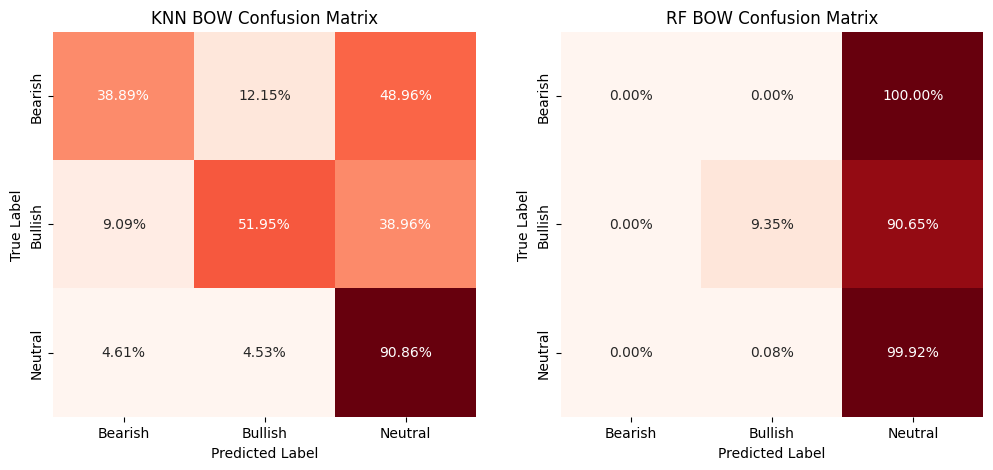

In [24]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(
    knn_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[0],
)
ax[0].set_title("KNN BOW Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(
    rf_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[1],
)
ax[1].set_title("RF BOW Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/bow_compare.png")
plt.show()

## <font color="#0ee071"> Word2Vec Data <a class="anchor" id="P2.2"></a></font>

[Back to Index](#index)


### <font color="#3676FF"> KNN Model <a class="anchor" id="P2.2.1"></a></font>

[Back to Index](#index)


In [25]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(KNN_GRID, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_vec, train_label)

    new_score = recall_score(
        validation_label, _knn.predict(validation_vec), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [00:11<00:00,  2.56it/s]

Best Recall: 0.46772
Grid: {'weights': 'distance', 'p': 3, 'n_neighbors': 5}


In [26]:
knn_classifier = (
    KNeighborsClassifier().set_params(**best_grid).fit(train_vec, train_label)
)
knn_predicted = knn_classifier.predict(validation_vec)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        knn_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.28      0.15      0.20       288
     Bullish       0.49      0.39      0.43       385
     Neutral       0.74      0.86      0.79      1236

    accuracy                           0.66      1909
   macro avg       0.50      0.47      0.47      1909
weighted avg       0.62      0.66      0.63      1909



### <font color="#3676FF"> Random Forest Model <a class="anchor" id="P2.2.2"></a></font>

[Back to Index](#index)


In [27]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(RF_GRID, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_vec, train_label)

    new_score = recall_score(
        validation_label, _rf.predict(validation_vec), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [00:26<00:00,  1.13it/s]

Best Recall: 0.44129
Grid: {'n_estimators': 160, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}


In [28]:
rf_classifier = (
    RandomForestClassifier().set_params(**best_grid).fit(train_vec, train_label)
)

rf_predicted = rf_classifier.predict(validation_vec)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        rf_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.75      0.02      0.04       288
     Bullish       0.58      0.34      0.43       385
     Neutral       0.71      0.96      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.68      0.44      0.43      1909
weighted avg       0.69      0.69      0.62      1909



### <font color="#3676FF"> Model Analysis <a class="anchor" id="P2.2.3"></a></font>

[Back to Index](#index)


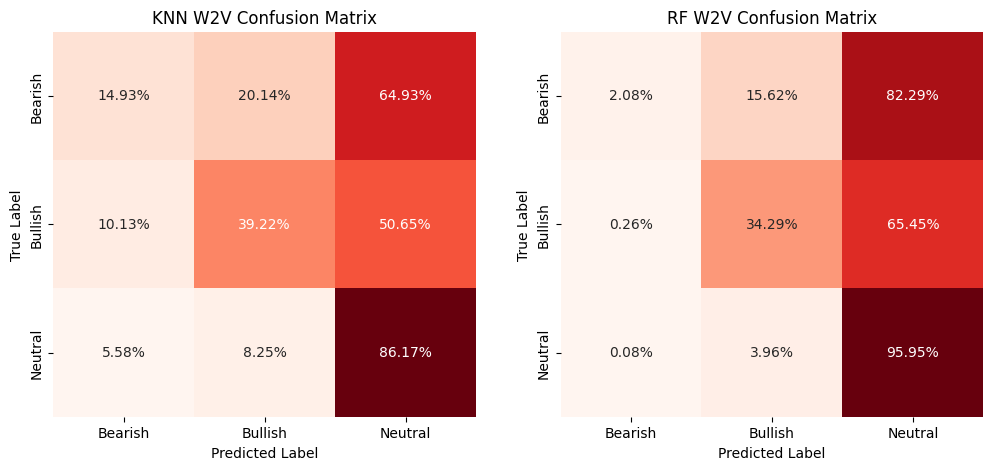

In [29]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(
    knn_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[0],
)
ax[0].set_title("KNN W2V Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(
    rf_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[1],
)
ax[1].set_title("RF W2V Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/w2v_compare.png")
plt.show()

## <font color="#0ee071"> Transformers Data <a class="anchor" id="P2.3"></a></font>

[Back to Index](#index)


### <font color="#3676FF"> KNN Model <a class="anchor" id="P2.3.1"></a></font>

[Back to Index](#index)


In [30]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(KNN_GRID, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_trans, train_label)

    new_score = recall_score(
        validation_label, _knn.predict(validation_trans), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [03:51<00:00,  7.71s/it]

Best Recall: 0.60388
Grid: {'weights': 'uniform', 'p': 1, 'n_neighbors': 5}


In [31]:
knn_classifier = (
    KNeighborsClassifier().set_params(**best_grid).fit(train_trans, train_label)
)
knn_predicted = knn_classifier.predict(validation_trans)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        knn_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.42      0.47      0.44       288
     Bullish       0.51      0.55      0.53       385
     Neutral       0.84      0.79      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.59      0.60      0.59      1909
weighted avg       0.71      0.69      0.70      1909



### <font color="#3676FF"> Random Forest Model <a class="anchor" id="P2.3.2"></a></font>

[Back to Index](#index)


In [32]:
best_score = -float("inf")
best_grid: dict[str, str | int] = {}

for g in tqdm.tqdm(ParameterSampler(RF_GRID, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_trans, train_label)

    new_score = recall_score(
        validation_label, _rf.predict(validation_trans), average="macro"
    )
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print(f"Best Recall: {best_score:0.5f}")
print("Grid:", best_grid)

100%|██████████| 30/30 [01:04<00:00,  2.14s/it]

Best Recall: 0.38145
Grid: {'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_depth': 9, 'criterion': 'entropy'}


In [33]:
rf_classifier = (
    RandomForestClassifier()
    .set_params(**best_grid)
    .fit(train_trans, train_label)
)

rf_predicted = rf_classifier.predict(validation_trans)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(
    classification_report(
        validation_label,
        rf_predicted,
        target_names=("Bearish", "Bullish", "Neutral"),
    )
)

              precision    recall  f1-score   support

     Bearish       0.83      0.02      0.03       288
     Bullish       0.65      0.14      0.23       385
     Neutral       0.67      0.99      0.80      1236

    accuracy                           0.67      1909
   macro avg       0.72      0.38      0.36      1909
weighted avg       0.69      0.67      0.57      1909



### <font color="#3676FF"> Model Analysis <a class="anchor" id="P2.3.3"></a></font>

[Back to Index](#index)


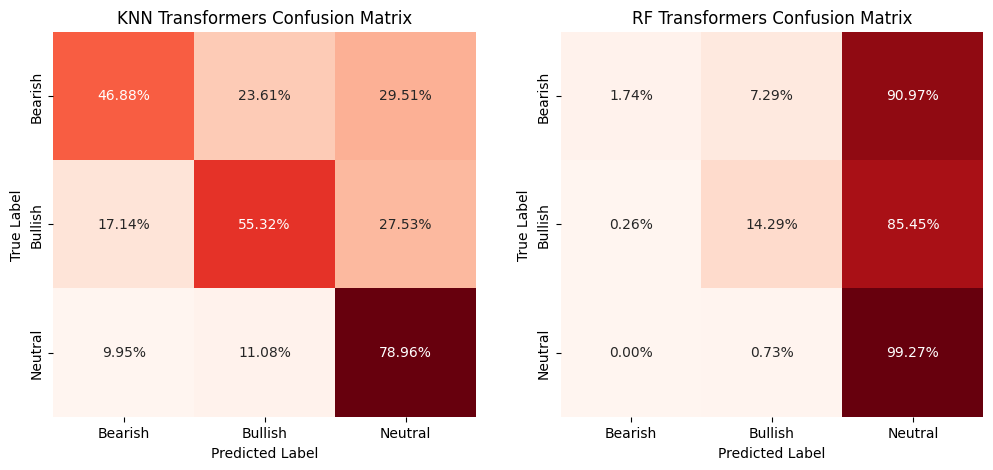

In [34]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(
    knn_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[0],
)
ax[0].set_title("KNN Transformers Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(
    rf_cm,
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax[1],
)
ax[1].set_title("RF Transformers Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/trans_compare.png")
plt.show()

## <font color="#0ee071"> Transformer Classifier <a class="anchor" id="P2.4"></a></font>

[Back to Index](#index)


In [35]:
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 5
LR = 2e-5
NUM_LABELS = 3

### <font color="#3676FF"> BERT Base Multilingual Cased <a class="anchor" id="P2.4.1"></a></font>

[Back to Index](#index)


In [36]:
transformer_classifier_result = train_model(
    train,
    validation,
    "bert-base-multilingual-cased",
    max_length=MAX_LEN,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    num_labels=NUM_LABELS,
    device=DEVICE,
    seed=SEED,
)

tokenizer = transformer_classifier_result["tokenizer"]
model = transformer_classifier_result["model"]
validation_metrics = transformer_classifier_result["final_validation_metrics"]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:46<03:05, 46.36s/it]

bert-base-multilingual-cased | epoch 1/5 | train_loss=0.7877 | val_weighted_f1=0.7885 | val_macro_f1=0.7300


 40%|████      | 2/5 [01:32<02:19, 46.34s/it]

bert-base-multilingual-cased | epoch 2/5 | train_loss=0.4819 | val_weighted_f1=0.8106 | val_macro_f1=0.7644


...

 80%|████████  | 4/5 [03:05<00:46, 46.41s/it]

bert-base-multilingual-cased | epoch 4/5 | train_loss=0.2219 | val_weighted_f1=0.8417 | val_macro_f1=0.7908


100%|██████████| 5/5 [03:51<00:00, 46.34s/it]

bert-base-multilingual-cased | epoch 5/5 | train_loss=0.1372 | val_weighted_f1=0.8341 | val_macro_f1=0.7829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
print(validation_metrics["classification_report"])

              precision    recall  f1-score   support

     Bearish     0.6667    0.7500    0.7059       288
     Bullish     0.7121    0.8416    0.7714       385
     Neutral     0.9372    0.8568    0.8952      1236

    accuracy                         0.8376      1909
   macro avg     0.7720    0.8161    0.7908      1909
weighted avg     0.8510    0.8376    0.8417      1909



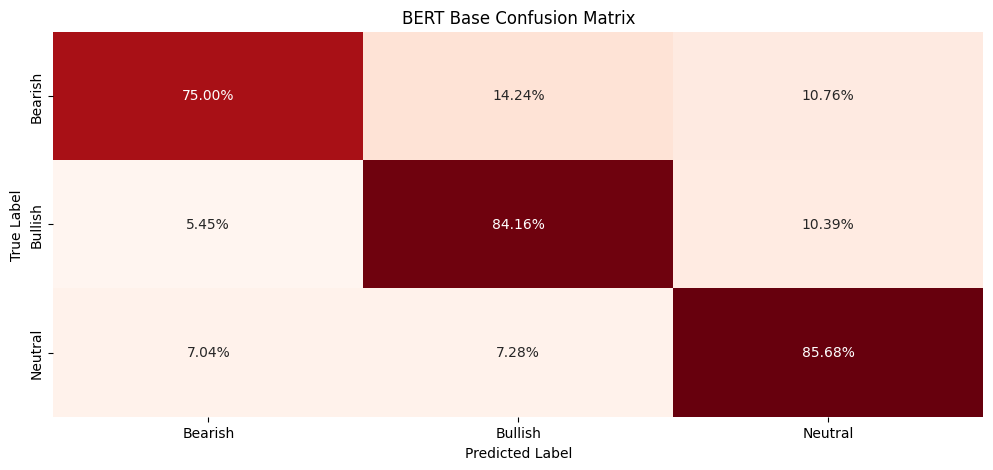

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    validation_metrics["confusion_matrix"],
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax,
)
ax.set_title("BERT Base Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.savefig("plots/bert_base_confusion_matrix.png")
plt.show()

### <font color="#3676FF"> BERT Base Multilingual Cased <a class="anchor" id="P2.4.2"></a></font>

[Back to Index](#index)


In [39]:
transformer_classifier_result = train_model(
    train,
    validation,
    "distilbert-base-multilingual-cased",
    max_length=MAX_LEN,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    num_labels=NUM_LABELS,
    device=DEVICE,
    seed=SEED,
)

tokenizer = transformer_classifier_result["tokenizer"]
model = transformer_classifier_result["model"]
validation_metrics = transformer_classifier_result["final_validation_metrics"]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:25<01:43, 25.95s/it]

distilbert-base-multilingual-cased | epoch 1/5 | train_loss=0.8568 | val_weighted_f1=0.7792 | val_macro_f1=0.7178


 40%|████      | 2/5 [00:52<01:18, 26.20s/it]

distilbert-base-multilingual-cased | epoch 2/5 | train_loss=0.5332 | val_weighted_f1=0.8168 | val_macro_f1=0.7584


...

 80%|████████  | 4/5 [01:44<00:26, 26.14s/it]

distilbert-base-multilingual-cased | epoch 4/5 | train_loss=0.1812 | val_weighted_f1=0.8220 | val_macro_f1=0.7655


100%|██████████| 5/5 [02:10<00:00, 26.15s/it]

distilbert-base-multilingual-cased | epoch 5/5 | train_loss=0.1267 | val_weighted_f1=0.8195 | val_macro_f1=0.7610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
print(validation_metrics["classification_report"])

              precision    recall  f1-score   support

     Bearish     0.5973    0.7569    0.6677       288
     Bullish     0.8284    0.7273    0.7746       385
     Neutral     0.9088    0.8867    0.8976      1236

    accuracy                         0.8350      1909
   macro avg     0.7782    0.7903    0.7800      1909
weighted avg     0.8456    0.8350    0.8381      1909



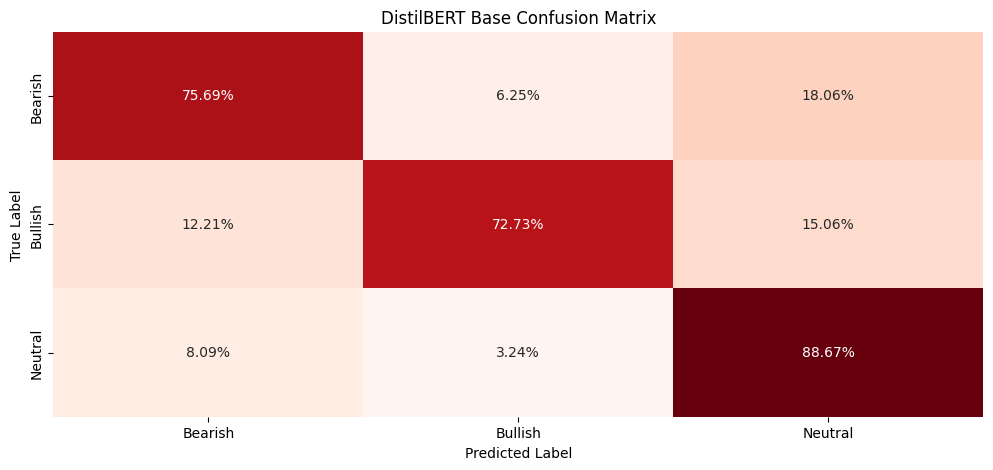

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    validation_metrics["confusion_matrix"],
    cmap="Reds",
    cbar=False,
    annot=True,
    fmt=".2%",
    xticklabels=("Bearish", "Bullish", "Neutral"),
    yticklabels=("Bearish", "Bullish", "Neutral"),
    ax=ax,
)
ax.set_title("DistilBERT Base Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.savefig("plots/distilbert_base_confusion_matrix.png")
plt.show()